In [36]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import healpy as hp

import matplotlib.pyplot as plt

import megatop
import megabuster


jax.config.update("jax_enable_x64", True)


In [37]:
# Preparing paths

path_scratch = '/pscratch/sd/m/mag/fast_MSS2_obsmat/'
path_precomputations = path_scratch

# Generating input CMB and input mask

In [38]:
from fgbuster import get_observation, get_instrument

nside = 128 
npix = 12*nside**2
nstokes = 2


frequencies = np.array([27, 39, 93, 145, 225, 280])

n_freq = len(frequencies)

# Get simulated map
instrument = get_instrument('SO_SAT')


np.random.seed(42)
input_freq_maps = get_observation(instrument, 'c1d0s0', nside=nside, noise=False)

np.random.seed(42)
input_cmb = get_observation(instrument, 'c1', nside=nside, noise=False)


0.0572967529296875

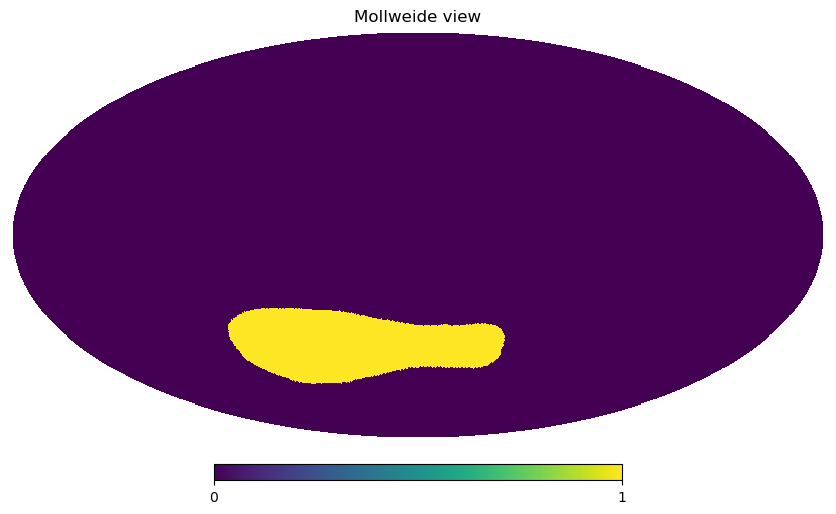

In [39]:
def make_mask(nhits_path, zero_threshold, nside):
    nhits_map = hp.read_map(nhits_path)
    nhits_smoothed = hp.smoothing(
        hp.ud_grade(nhits_map, nside, power=-2, dtype=np.float64),
        fwhm=np.pi/180)
    nhits_smoothed[nhits_smoothed < 0] = 0
    nhits_smoothed /= np.amax(nhits_smoothed)
    binary_mask = np.zeros_like(nhits_smoothed)
    binary_mask[nhits_smoothed > zero_threshold] = 1
    fsky = np.sum(binary_mask) / len(binary_mask)

    return binary_mask, fsky

nside_out = 128  # Output nside for the mask

# path_MSS = '/lustre/fswork/projects/rech/nih/commun/megatop/MSS2/ivar/'
path_MSS = '/global/cfs/cdirs/sobs/sims/mss-0002/RC1.r01/'
zero_threshold = 0.45
path_nhits = path_MSS+f"sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_ivar_healpix.fits"
mask_B, fsky = make_mask(path_nhits, zero_threshold, nside=nside_out)

theta, phi = hp.pix2ang(nside=nside_out, ipix=np.arange(mask_B.size), lonlat=True)

mask_south = np.zeros_like(mask_B)

mask_south[theta < 115] = 1
mask_south[theta > 280] = 1
mask_south[phi < -35] = 1
mask_south[phi > -15] = 0

mask_B_ring = mask_B * mask_south
mask_B_nest = hp.reorder(mask_B_ring, r2n=True)

mask_indices = mask_B_nest != 0

hp.mollview(mask_B_nest, nest=True)
f_sky = mask_B_nest.sum() / mask_B_nest.size
f_sky

In [40]:
hp.write_map(path_scratch + '/validation_MEGATOP_3/mask_B_ring.fits', mask_B_ring)

09-Sep-25 07:42:32 - WARNING: setting the output map dtype to [dtype('float64')]


OSError: File /pscratch/sd/m/mag/fast_MSS2_obsmat//validation_MEGATOP_3/mask_B_ring.fits already exists. If you mean to replace it then use the argument "overwrite=True".

# Preparing path and loading obsmat

In [ ]:
path_N = '/pscratch/sd/b/beringue/BB-AWG/MEGATOP/2501_obsmat_filtering/covmat/pixel_noise_cov_preprocessed.npy'

# Prepare the paths of observation matrices 

path_save_obsmat_file = "sobs_RC1.r01_SAT{}_mission_f{:03d}_4way_{}_sky_obsmat_healpix_"


all_incomplete_path_save_obsmat_file = [path_save_obsmat_file.format(4, freq, 'coadd') for freq in [30, 40]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(1, freq, 'coadd') for freq in [90, 150]]
all_incomplete_path_save_obsmat_file += [path_save_obsmat_file.format(3, freq, 'coadd') for freq in [230, 290]]

all_path_save_obsmat_file = [path_scratch + path for path in all_incomplete_path_save_obsmat_file]


n_pix = mask_B_nest.sum()

In [ ]:
# Preparing the inverse noise covariance matrix --------------------------------
print("Loading the inverse noise covariance matrix from", path_N, flush=True)
def load_N_matrix(path_N):
    N_matrix = np.load(path_N)
    if N_matrix.ndim != 2:
        output = []
        for i in range(N_matrix.shape[0]):
            output.append(hp.ud_grade(N_matrix[i], nside_out=nside, power=2))
        N_matrix = np.array(output)
    return N_matrix

N_matrix = load_N_matrix(path_N)



In [ ]:
np.save(path_scratch + '/validation_MEGATOP_3/pixel_noisecov_preprocessed.npy', N_matrix)

Here the full observation matrices are loaded to filter the input data

In [ ]:
%%time
indices_mask = np.arange(npix)[mask_indices]

# Retrieve mask indices for Q and U (omitting T)
mask_stacked = np.hstack((indices_mask + npix, indices_mask + 2*npix))

list_scipy_obsmat_masked = megabuster.io.load_all_obsmat(
    all_path_save_obsmat_file, size_obsmat=3*npix, kind='precomputations_scipy', mask_stacked=mask_stacked)

In [ ]:
%%time
freq_maps_preprocessed_TQU_masked = np.zeros((n_freq, 3, npix))

for i in range(n_freq):
    print(i)
    filtered_data = list_scipy_obsmat_masked[i].dot(
            hp.reorder(
                input_freq_maps[i,1:,...],r2n=True)[...,mask_indices].ravel()
            ).reshape((2, int(n_pix)))
    extended_data = np.zeros((2, npix))
    extended_data[:, mask_indices] = filtered_data
    freq_maps_preprocessed_TQU_masked[i,1:,...] = hp.reorder(
        extended_data, n2r=True)

freq_maps_preprocessed_QU_masked = freq_maps_preprocessed_TQU_masked[:,1:,:] * mask_B_ring

In [ ]:
np.save(path_scratch + '/validation_MEGATOP_3/freq_maps_preprocessed', freq_maps_preprocessed_TQU_masked)

In [ ]:
del list_scipy_obsmat_masked

And now we prepare the observation matrices to be used in the compsep

# Trying out MEGATOP implementation of MEGABUSTER

In [1]:
import os

# Set the environment variable to avoid printing the error message
os.environ["EQX_ON_ERROR"] = "nan"

import numpy as np
import jax
import healpy as hp

import matplotlib.pyplot as plt

import megatop
import megabuster


jax.config.update("jax_enable_x64", True)


In [2]:
from megatop import Config, DataManager


path_to_config = 'test_config.yaml'

config = Config.load_yaml(path_to_config)

manager = DataManager(config)


In [3]:
manager.get_obsmat_filenames()

[PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix.npz'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix.npz'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix.npz'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix.npz'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix.npz')]

In [4]:
manager.get_path_list_or_None('suffix_obsmat_scipy')

[PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_precompute'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_precompute'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_precompute'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_precompute'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_precompute'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_precompute')]

In [5]:
manager.get_path_list_or_None('suffix_eigen_decomp')

[PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_eigendecomp'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_eigendecomp'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_eigendecomp'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_eigendecomp'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_eigendecomp'),
 PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_eigendecomp')]

In [6]:
print(config.parametric_sep_pars.get_minimize_options_as_dict())
print(config.parametric_sep_pars.minimize_tol)
print(config.parametric_sep_pars.minimize_method)

print(config.parametric_sep_pars.get_megabuster_options_as_dict())

{'disp': False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 20, 'ftol': 1e-12}
1e-06
personalized
{'cg_maxiter': 200, 'cg_tol': 1e-06, 'use_preconditioner_diag': False, 'use_preconditioner_pinv': True}


In [7]:
from megatop.utils.precomputations import megabuster_precomputations

In [8]:
%%time
megabuster_precomputations(manager, config)

Starting saving obsmat precomputation...
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix.npz
## Files /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_precompute_data.npy, /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_precompute_row_indices.npy, /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_precompute_column_indices.npy already exist, skipping computation.
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix.npz
## Files /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_precompute_data.npy, /pscratch/sd/m/mag/fast_MSS2_obsmat/va

09-Sep-25 08:25:35 - INFO: Elapsed time [apply-binary-mask]: 11.057 ms


## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_eigendecomp.npz already exists, skipping computation.
## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_eigendecomp.npz already exists, skipping computation.
## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_eigendecomp.npz already exists, skipping computation.
## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_eigendecomp.npz already exists, skipping computation.
## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_eigendecomp.npz already exists, skipping computation.
## File /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f290_4way

09-Sep-25 08:25:35 - INFO: Elapsed time [precompute-obsmat]: 1 m 12 s


CPU times: user 40.1 s, sys: 32.1 s, total: 1min 12s
Wall time: 1min 12s


In [9]:
manager.path_to_pixel_noisecov, os.path.exists(manager.path_to_pixel_noisecov)

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/pixel_noisecov_preprocessed.npy'),
 True)

In [10]:
test_noise_cov = np.load(manager.path_to_pixel_noisecov)

In [11]:
test_noise_cov.shape

(6, 3, 196608)

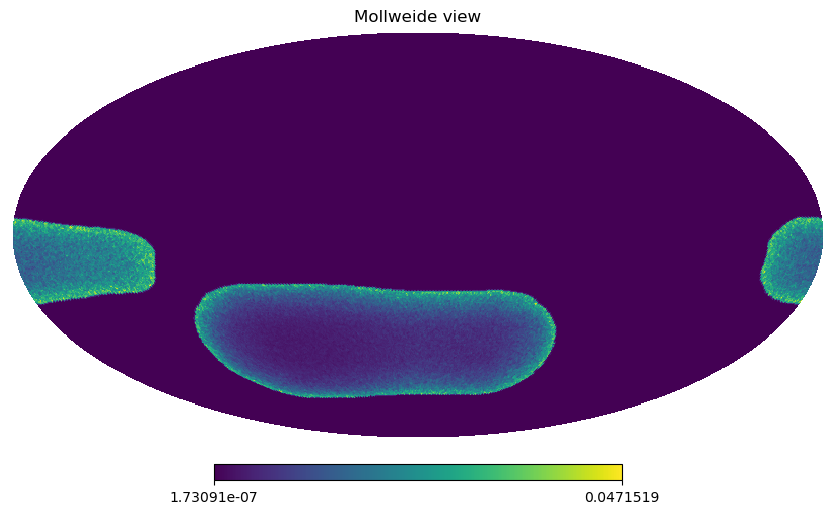

In [12]:
hp.mollview(test_noise_cov[0,1])

In [13]:
manager.get_path_to_preprocessed_maps(), os.path.exists(manager.get_path_to_preprocessed_maps())

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/freq_maps_preprocessed.npy'),
 True)

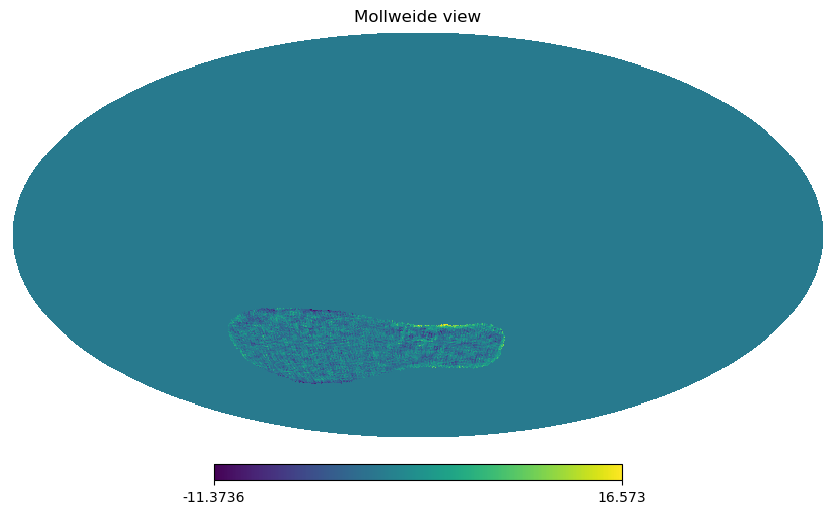

In [14]:
test_maps = np.load(manager.get_path_to_preprocessed_maps())
hp.mollview(test_maps[0,1])#, max=100, min=-100)

In [15]:
test_maps.shape

(6, 3, 196608)

In [16]:
manager.path_to_binary_mask, os.path.exists(manager.path_to_binary_mask)

(PosixPath('/pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/mask_B_ring.fits'),
 True)

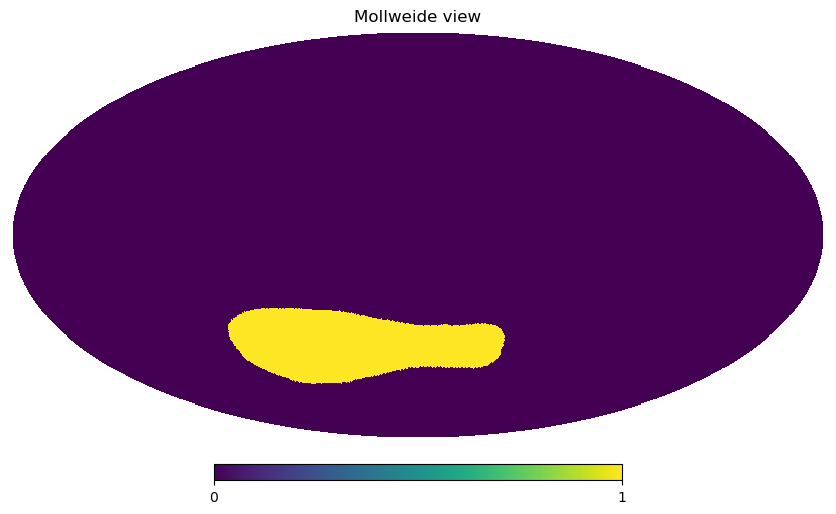

In [17]:
hp.mollview(hp.read_map(manager.path_to_binary_mask))

In [18]:
config.frequencies

[27, 39, 93, 145, 225, 280]

In [19]:
config.parametric_sep_pars.get_minimize_options_as_dict()

{'disp': False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 20, 'ftol': 1e-12}

In [20]:
config.parametric_sep_pars.include_synchrotron

True

In [3]:
from megatop.pipeline.parametric_separater import megabuster_comp_sep

In [4]:
%%time
res_test = megabuster_comp_sep(
    manager,
    config
    )

09-Sep-25 12:28:27 - INFO: Elapsed time [load-covmat]: 33.273 ms
09-Sep-25 12:28:27 - INFO: Elapsed time [load-maps]: 27.363 ms


Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f030_4way_coadd_sky_obsmat_healpix_precompute
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT4_mission_f040_4way_coadd_sky_obsmat_healpix_precompute
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f090_4way_coadd_sky_obsmat_healpix_precompute
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT1_mission_f150_4way_coadd_sky_obsmat_healpix_precompute
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f230_4way_coadd_sky_obsmat_healpix_precompute
Loading obsmat from path /pscratch/sd/m/mag/fast_MSS2_obsmat/validation_MEGATOP_3/sobs_RC1.r01_SAT3_mission_f290_4way_coadd_sky_obsmat_healpix_precompute
Building and loading matrix eigen decomposition from the list of paths [Posi

09-Sep-25 12:39:34 - INFO: Elapsed time [load-obsmat]: 11 m 06 s
09-Sep-25 12:39:34 - INFO: Elapsed time [apply-binary-mask]: 13.447 ms
09-Sep-25 12:39:34 - INFO: Elapsed time [apply-binary-mask]: 13.458 ms


Precomputing the right-hand side of the CG equation . . .
Right-hand side of the CG equation precomputed!
Launching minimization!!
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Using pseudo-inverse preconditioner
Assuming no patches for the preconditioner computation
Converged in 28 iterations
Converged in 28 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 29 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations
Converged in 28 iterations

09-Sep-25 13:05:02 - INFO: Success: True -> Optimization finished after 1 iterations out of 20 allowed.
09-Sep-25 13:05:02 - INFO: Spectral parameters ['beta_dust', 'beta_pl'] -> [ 1.54000001 -2.99999992]
09-Sep-25 13:05:02 - INFO: Elapsed time [do-compsep]: 25 m 28 s


Converged in 29 iterations
CPU times: user 1d 48min 13s, sys: 33min 24s, total: 1d 1h 21min 38s
Wall time: 36min 34s


In [5]:
res_test.x

array([ 1.54000001, -2.99999992])